From https://www.tensorflow.org/guide/basics

TensorFlow (TF) is an end-to-end platform for machine learning. It supports the following:

1. Multidimensional-array based numeric computation (similar to NumPy.)
2. GPU and distributed processing
3. Automatic differentiation
4. Model construction, training, and export
5. And more

---

Some important points about TF.

* TensorFlow was developed by the Google Brain team for internal use at Google. Then, it was made open source in November 2015.
* Keras is an API (application programming interface) for deep learning calculations. API means that Keras defines a specific interface to write codes.
* Keras was written in Python.
* Keras has multiple backends (libraries that are
responsible for doing the actual calculations): TensorFlow,
CNTK, Theano.
* Keras is focused on easy and fast prototyping, through
user friendliness, modularity, and extensibility.
* Although TF can be used as a backend for Keras, it is
recommended to use tf.keras, which is the implementation
of Keras in TF.





---

**Load essential libraries**

---

In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-whitegrid')
%matplotlib inline

import tensorflow as tf

C:\Users\ATISHAY SG\AppData\Local\Temp\ipykernel_10228\3405315510.py:3: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn-whitegrid')


---

**Check TensorFlow version**

---

In [2]:
tf.__version__

'2.14.0'

---
Introduction to tensors from https://www.tensorflow.org/guide/tensor

---

---

Introduction to variables from https://www.tensorflow.org/guide/variable

---

---

Automatic differentiation using TF (https://www.tensorflow.org/guide/autodiff)

Example: calculate the sensitivity of $L(w) = 4w+w^3$ w.r.t. the input $w$ at $w=1.$

Sensitivity $\nabla_wL = 4+3w^2,$ which at $w=1$ is equal to $4+3\times1^2=7.$

---

The gradient at w=1 is: 10.750000


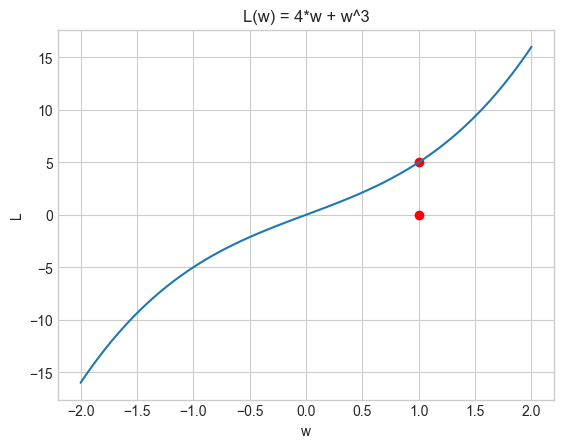

In [2]:
#plot a graph for the equation L(w) = 4*w + w^3 at w=1
w = np.linspace(-2,2,100)
#use a lambda function to define the equation
L = lambda w: 4*w + tf.math.pow(w,3)
plt.plot(w,L(w))
plt.title('L(w) = 4*w + w^3')
plt.xlabel('w')
plt.ylabel('L')
#scatter plot
plt.scatter(1,5, c = 'red')
plt.scatter(1,0, c = 'red');

w = tf.Variable(1.5)
with tf.GradientTape() as g:
    L = 4*w + tf.math.pow(w,3)

gradL_w = g.gradient(L,w)
print('The gradient at w=1 is: %f' %(gradL_w)) 


---

Example: calculate the sensitivity of $L(w_1,w_2) = w_1+w_2^2$ w.r.t. the inputs $w_1, w_2$ at $w_1=1, w_2=2.$

Setting $\mathbf{w} = \begin{bmatrix}w_1\\w_2\end{bmatrix},$ sensitivity $\nabla_\mathbf{w}L= \begin{bmatrix}\nabla_{w_1}(w_1+w_2^2)\\\nabla_{w_2}(w_1+w_2^2)\end{bmatrix} = \begin{bmatrix}1\\2w_2\end{bmatrix},$

 which at $w_1=1,w_2=2$ is equal to $\begin{bmatrix}1\\4\end{bmatrix}.$

 ---

In [3]:
w1 = tf.Variable(1.0)
w2 = tf.Variable(2.0)

with tf.GradientTape() as g:
    L = w1 + tf.math.pow(w2, 2)

gradL_w1, gradL_w2 = g.gradient(L, [w1, w2])
print('The gradient at w1=1 and w2=2 is: %f and %f' %(gradL_w1, gradL_w2))

The gradient at w1=1 and w2=2 is: 1.000000 and 4.000000


---

In TF, we can control which input is considered an independent variable versus a constant value.

`gradient` will return `None` when the input is not a `tf.Variable`.

---

In [4]:
#Independent variable
w1 = tf.Variable(1.0, name='survived')

#A tf.constant is not a variable
c1 = tf.constant(-2.0, name='survived')  

#Treat a tf.Variable like a constant
w2 = tf.Variable(2.0, name='second layer weights', trainable = False)

#A tf.Variable plus a tensor object is treated as a tensor object
c2 = tf.constant(10.0, name='c2') + 1.0

#Define a variable that will not be used in the computation
w3 = tf.Variable(0.0, name='third layer weights')

with tf.GradientTape() as g:
    L = (w1 + c1) ** 2 + w2**3 + 4*c2

grad  = g.gradient(L, [w1, w2, w3, c1, c2])

for dw in grad:
    print(dw)

tf.Tensor(-2.0, shape=(), dtype=float32)
None
None
None
None


---

A `tf.Tensor` can be used as a variable using the `watch` function.

For example, consider calculating the sensitivity of $L(w) = w^4$ at $w=-3.$

The sensitivity is $\nabla_wL = 4w^3,$ which at $w=-3$ is equal to $4\times(-3)^3 = -108.$

---

In [46]:
x = tf.constant(-3)

with tf.GradientTape() as g:
    g.watch(x)
    L = x ** 4 

gradL_x = g.gradient(L, x)
print((gradL_x))

None


L(w) = ||w||^2, where w is a 8 vector. gradw(L) = 2w. Suppose w = ([0.1, 0, 0.1, 0, 0.1, 0, 0.1, 0]). Calculate the gradient gradw(L) using Gradient tape. 

In [16]:
w = tf.Variable([0.1, 0, 0.1, 0, 0.1, 0, 0.1, 0])
with tf.GradientTape() as g:
    L = tf.norm(w)**2

gradL_w = g.gradient(L,w)
print(gradL_w) 


tf.Tensor([0.2 0.  0.2 0.  0.2 0.  0.2 0. ], shape=(8,), dtype=float32)


a = softmax(z) = softmax(Wx). Assume 2 output classes - (diabetic/not-diabetic)  
x = ([76.0, 120.0, 37.5])    
W = ([w11, w12, w13, w14], 
     [w21, w22, w23, w24])   
       = ([0.01, 0.01, 0.01, 0.01],
     [0.01, 0.01, 0.01, 0.01])

In [36]:
W = tf.Variable([[0.01, 0.01, 0.01, 0.01],
                 [0.01, 0.01, 0.01, 0.01]])
x = tf.constant([76.0, 120.0, 37.5])

with tf.GradientTape() as g:
    softmax = tf.nn.softmax(W)

grad_softmax = g.gradient(softmax, W)
print(grad_softmax)

tf.Tensor(
[[0. 0. 0. 0.]
 [0. 0. 0. 0.]], shape=(2, 4), dtype=float32)


In [45]:
# Calculate the softmax gradient
xb = tf.constant([76.0, 120.0, 37.5, 1])
# xb = tf.concat([x, tf.ones(1)], axis=0)

W = 0.01 * tf.ones([2, 4])

with tf.GradientTape() as g:
    z = tf.linalg.matvec(W, xb)
    a = tf.nn.softmax(z)

grad_softmax = g.gradient(a, W)
print(grad_softmax)



None


define w as a variable and gradient should 2x4x2 object

---

We can use multiple tensor variables as input. This just means we calculate the sensitivity w.r.t. all the variables in the tensor.

For example, consider calculating the sensitivity of $L(w) = w[0]^2+w[1]^2$ at $w[0] = 1, w[1] = -3.$

---

---

When `g.gradient` is called with a tensor dependent variable (tensor target), it returns the sum of the sensitivities for each component of the target variable.

---

---

By default, when we call `g.gradient`, all resources required to compute the gradient are released. This allows saving memory. However, there are cases when we want to call `g.gradient` several times, for example, to differentiate different chained functions. In that case, we must use the option `persistent=True`.

---

---

We can easily calculate sensitivies of functions and plot them.

---

In [2]:
x = tf.Variable([1.0, 2.0, 3.0])

with tf.GradientTape(persistent = True) as g:
    # y = tf.Variable([x[0]+x[1]+x[2], x[0]**2+x[1]**2+x[2]**2])
    y = tf.convert_to_tensor([x[0]+x[1]+x[2], x[0]**2+x[1]**2+x[2]**2])
    
print(type(y).__name__)
print(g.gradient(y, x))

EagerTensor
tf.Tensor([3. 5. 7.], shape=(3,), dtype=float32)


In [3]:
x = tf.Variable([1.0, 2.0, 3.0])

with tf.GradientTape(persistent=True) as g:
  #In which of the following is the variable x watched by the gradient tape?
  y1 = x**2
  y2 = tf.reduce_sum(x**2)
  y3 = tf.stack([tf.reduce_sum(x), tf.reduce_sum(x**2)])
  y4 = tf.Variable([tf.reduce_sum(x), tf.reduce_sum(x**2)])
  y5 = tf.convert_to_tensor([tf.reduce_sum(x), tf.reduce_sum(x**2)])

print("x: ", type(x).__name__)
print("y1: ",y1)
print("y2: ",y2)
print("y3: ",y3)
print("y4: ",y4)
print("y5: ",y5)

print("------------------------------------------------")
print("y1: ", type(y1).__name__)
print("y2: ", type(y2).__name__)
print("y3: ", type(y3).__name__)
print("y4: ", type(y4).__name__)
print("y5: ", type(y5).__name__)

print("------------------------------------------------")
print("y1: ", g.gradient(y1, x))
print("y2: ", g.gradient(y2, x))
print("y3: ", g.gradient(y3, x))
print("y4: ", g.gradient(y4, x))
print("y5: ", g.gradient(y5, x))

x:  ResourceVariable
y1:  tf.Tensor([1. 4. 9.], shape=(3,), dtype=float32)
y2:  tf.Tensor(14.0, shape=(), dtype=float32)
y3:  tf.Tensor([ 6. 14.], shape=(2,), dtype=float32)
y4:  <tf.Variable 'Variable:0' shape=(2,) dtype=float32, numpy=array([ 6., 14.], dtype=float32)>
y5:  tf.Tensor([ 6. 14.], shape=(2,), dtype=float32)
------------------------------------------------
y1:  EagerTensor
y2:  EagerTensor
y3:  EagerTensor
y4:  ResourceVariable
y5:  EagerTensor
------------------------------------------------
y1:  tf.Tensor([2. 4. 6.], shape=(3,), dtype=float32)
y2:  tf.Tensor([2. 4. 6.], shape=(3,), dtype=float32)
y3:  tf.Tensor([3. 5. 7.], shape=(3,), dtype=float32)
y4:  None
y5:  tf.Tensor([3. 5. 7.], shape=(3,), dtype=float32)


In [5]:
print('g.jacobian(y1, x): ', g.jacobian(y1, x))

g.jacobian(y1, x):  tf.Tensor(
[[2. 0. 0.]
 [0. 4. 0.]
 [0. 0. 6.]], shape=(3, 3), dtype=float32)


In [4]:
print("y1: ", g.gradient(y1, x).shape)

y1:  (3,)
